In [ ]:
%pip install langgraph

In [17]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [ ]:
#State
class GraphState(TypedDict):
    message:str

In [12]:
def greeting_node(state:GraphState)->GraphState:
    """Node to add a greeting message"""
    state["message"]=f"Hi {state["message"]}."
    return state

In [13]:
def helping_node(state:GraphState)->GraphState:
    """Node to add a helping message"""
    state["message"] += " How can I help you today?"
    return state

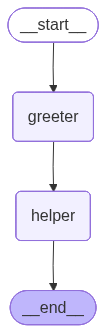

In [18]:
builder = StateGraph(GraphState)

builder.add_node("greeter", greeting_node)
builder.add_node("helper", helping_node)

builder.add_edge(START, "greeter")
builder.add_edge("greeter", "helper")
builder.add_edge("helper", END)

graph = builder.compile()
graph

In [20]:
print(graph.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	greeter(greeter)
	helper(helper)
	__end__([<p>__end__</p>]):::last
	__start__ --> greeter;
	greeter --> helper;
	helper --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [22]:
print(graph.get_graph().draw_ascii())

+-----------+  
| __start__ |  
+-----------+  
      *        
      *        
      *        
 +---------+   
 | greeter |   
 +---------+   
      *        
      *        
      *        
  +--------+   
  | helper |   
  +--------+   
      *        
      *        
      *        
 +---------+   
 | __end__ |   
 +---------+   


In [24]:
start_state = {"message":"Apoorva"}
graph.invoke(start_state)

{'message': 'Hi Apoorva. How can I help you today?'}

In [27]:
graph_events = graph.stream(start_state)
for event in graph_events:
    print(event)

{'greeter': {'message': 'Hi Apoorva.'}}
{'helper': {'message': 'Hi Apoorva. How can I help you today?'}}
